In [1]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install --upgrade keras

Note: you may need to restart the kernel to use updated packages.


In [3]:
from __future__ import division, print_function, absolute_import
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation,Flatten
from keras.layers import Conv2D, MaxPooling2D
from keras.layers import BatchNormalization
from keras.optimizers import SGD

import keras.backend as K
import keras.utils

In [4]:
import matplotlib.pyplot as plt
import numpy as np

In [5]:
nb_Classes=10
(x_train,y_train),(x_test,y_test)=mnist.load_data()
print("X_train original shape",x_train.shape)
print("Y_train original shape",y_train.shape)


X_train original shape (60000, 28, 28)
Y_train original shape (60000,)


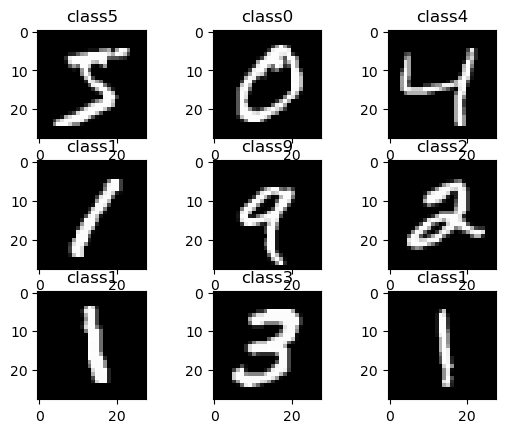

In [6]:
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i],cmap='gray',interpolation='none')
    plt.title("class{}".format(y_train[i]))

plt.show()

In [7]:

x_train =x_train.reshape(60000,784)
x_test=x_test.reshape(10000,784)
x_train=x_train.astype('float32')
x_test=x_test.astype('float32')
x_train/=255
x_test/=255
print("Training matrix shape",x_train.shape)
print("Testing matrix shape",x_test.shape)

y_train=keras.utils.to_categorical(y_train, nb_Classes)
y_test=keras.utils.to_categorical(y_test, nb_Classes)

Training matrix shape (60000, 784)
Testing matrix shape (10000, 784)


In [8]:
def alexnet():
    model=Sequential()
    model.add(Conv2D(63,(3,3),padding='same',input_shape=(28,28,1)))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D(pool_size=(2,2)))
    
    model.add(Conv2D(128,(7,7),padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D(pool_size=(2,2)))
    
    model.add(Conv2D(192,(3,3),padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D(pool_size=(2,2)))
    
    model.add(Conv2D(256,(3,3),padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D(pool_size=(1,1)))
    
    model.add(Flatten())
    model.add(Dense(4096))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Dense(4096))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Dense(10))
    model.add(BatchNormalization())
    model.add(Activation('softmax'))
    return model

In [9]:
model=alexnet()
optim=SGD(learning_rate=0.0001)
model.compile(loss='categorical_crossentropy',optimizer=optim,metrics=['acc'])

C:\Users\hansh\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.fit(x_train.reshape(60000,28,28,1),y_train,batch_size=50,epochs=3,
          validation_data=(x_test.reshape(10000,28,28,1),y_test),verbose=1)

Epoch 1/3
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 220s 182ms/step - acc: 0.8023 - loss: 0.9592 - val_acc: 0.9230 - val_loss: 0.6190
Epoch 2/3
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 249s 208ms/step - acc: 0.9148 - loss: 0.6747 - val_acc: 0.9447 - val_loss: 0.5411
Epoch 3/3
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 257s 214ms/step - acc: 0.9330 - loss: 0.6131 - val_acc: 0.9556 - val_loss: 0.4995


In [11]:
score=model.evaluate(x_test.reshape(10000,28,28,1),y_test,verbose=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - acc: 0.9556 - loss: 0.4995


In [12]:
predicted_classes=model.predict(x_test.reshape(10000,28,28,1))

313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 36ms/step


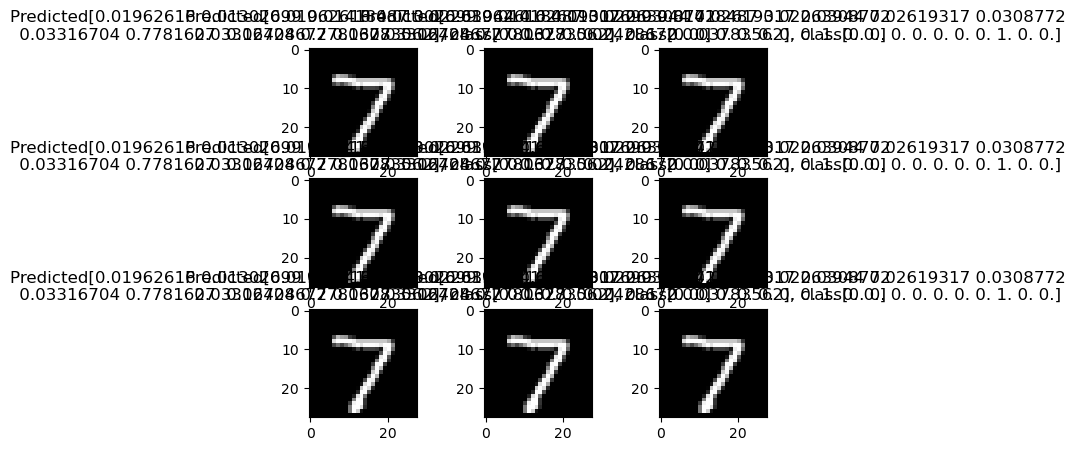

In [13]:
incorrect_indices = np.where(predicted_classes != y_test)[0]
plt.figure()
for i, incorrect in enumerate(incorrect_indices[:9]):
    plt.subplot(3,3,i+1)
    plt.imshow(x_test[incorrect].reshape(28,28),cmap='gray',interpolation='none')
    plt.title("Predicted{}, class{}".format(predicted_classes[incorrect],y_test[incorrect]))

plt.show()

In [14]:
model.save("./myAlexnetmodel.keras")

In [15]:
import glob
import numpy as np
import os
import shutil
np.random.seed(42)


In [16]:
files = glob.glob('dogs-vs-cats/*')

cat_files = [fn for fn in files if 'cat' in fn]
dog_files = [fn for fn in files if 'dog' in fn]


In [17]:
dog_files

['dogs-vs-cats\\cat.10001.jpg',
 'dogs-vs-cats\\cat.10009.jpg',
 'dogs-vs-cats\\cat.10011.jpg',
 'dogs-vs-cats\\cat.10015.jpg',
 'dogs-vs-cats\\cat.10021.jpg',
 'dogs-vs-cats\\cat.10041.jpg',
 'dogs-vs-cats\\cat.10050.jpg',
 'dogs-vs-cats\\cat.1006.jpg',
 'dogs-vs-cats\\cat.10067.jpg',
 'dogs-vs-cats\\cat.10077.jpg',
 'dogs-vs-cats\\cat.10081.jpg',
 'dogs-vs-cats\\cat.10085.jpg',
 'dogs-vs-cats\\cat.10093.jpg',
 'dogs-vs-cats\\cat.10102.jpg',
 'dogs-vs-cats\\cat.10109.jpg',
 'dogs-vs-cats\\cat.10115.jpg',
 'dogs-vs-cats\\cat.10119.jpg',
 'dogs-vs-cats\\cat.10126.jpg',
 'dogs-vs-cats\\cat.1013.jpg',
 'dogs-vs-cats\\cat.10137.jpg',
 'dogs-vs-cats\\cat.1014.jpg',
 'dogs-vs-cats\\cat.10145.jpg',
 'dogs-vs-cats\\cat.10151.jpg',
 'dogs-vs-cats\\cat.10156.jpg',
 'dogs-vs-cats\\cat.10169.jpg',
 'dogs-vs-cats\\cat.1017.jpg',
 'dogs-vs-cats\\cat.10184.jpg',
 'dogs-vs-cats\\cat.10194.jpg',
 'dogs-vs-cats\\cat.10199.jpg',
 'dogs-vs-cats\\cat.1020.jpg',
 'dogs-vs-cats\\cat.10203.jpg',
 'dogs-vs-cat

In [18]:
cat_files

['dogs-vs-cats\\cat.10001.jpg',
 'dogs-vs-cats\\cat.10009.jpg',
 'dogs-vs-cats\\cat.10011.jpg',
 'dogs-vs-cats\\cat.10015.jpg',
 'dogs-vs-cats\\cat.10021.jpg',
 'dogs-vs-cats\\cat.10041.jpg',
 'dogs-vs-cats\\cat.10050.jpg',
 'dogs-vs-cats\\cat.1006.jpg',
 'dogs-vs-cats\\cat.10067.jpg',
 'dogs-vs-cats\\cat.10077.jpg',
 'dogs-vs-cats\\cat.10081.jpg',
 'dogs-vs-cats\\cat.10085.jpg',
 'dogs-vs-cats\\cat.10093.jpg',
 'dogs-vs-cats\\cat.10102.jpg',
 'dogs-vs-cats\\cat.10109.jpg',
 'dogs-vs-cats\\cat.10115.jpg',
 'dogs-vs-cats\\cat.10119.jpg',
 'dogs-vs-cats\\cat.10126.jpg',
 'dogs-vs-cats\\cat.1013.jpg',
 'dogs-vs-cats\\cat.10137.jpg',
 'dogs-vs-cats\\cat.1014.jpg',
 'dogs-vs-cats\\cat.10145.jpg',
 'dogs-vs-cats\\cat.10151.jpg',
 'dogs-vs-cats\\cat.10156.jpg',
 'dogs-vs-cats\\cat.10169.jpg',
 'dogs-vs-cats\\cat.1017.jpg',
 'dogs-vs-cats\\cat.10184.jpg',
 'dogs-vs-cats\\cat.10194.jpg',
 'dogs-vs-cats\\cat.10199.jpg',
 'dogs-vs-cats\\cat.1020.jpg',
 'dogs-vs-cats\\cat.10203.jpg',
 'dogs-vs-cat

In [19]:
len(cat_files), len(dog_files)

(4726, 4726)

In [20]:

cat_train = np.random.choice(cat_files, size=1500, replace=False)
dog_train = np.random.choice(dog_files, size=1500, replace=False)
cat_files = list(set(cat_files) - set(cat_train))
dog_files = list(set(dog_files) - set(dog_train))

In [21]:
len(cat_train), len(dog_train)

(1500, 1500)

In [22]:
len(cat_files), len(dog_files)

(3226, 3226)

In [23]:
cat_val = np.random.choice(cat_files, size=500, replace=False)
dog_val = np.random.choice(dog_files, size=500, replace=False)
cat_files = list(set(cat_files) - set(cat_val))
dog_files = list(set(dog_files) - set(dog_val))

In [24]:
len(cat_files), len(dog_files)

(2726, 2726)

In [25]:
len(cat_val), len(dog_val)

(500, 500)

In [26]:
cat_test = np.random.choice(cat_files, size=500, replace=False)
dog_test = np.random.choice(dog_files, size=500, replace=False)

In [27]:
print('Cat datasets:', cat_train.shape, cat_val.shape, cat_test.shape)
print('Dog datasets:', dog_train.shape, dog_val.shape, dog_test.shape)

Cat datasets: (1500,) (500,) (500,)
Dog datasets: (1500,) (500,) (500,)


In [28]:
train_dir = 'training_data'
val_dir   = 'validation_data'
test_dir  = 'test_data'


In [29]:
train_files     = np.concatenate([cat_train, dog_train])
validate_files  = np.concatenate([cat_val, dog_val])
test_files      = np.concatenate([cat_test, dog_test])

In [30]:
os.mkdir(train_dir) if not os.path.isdir(train_dir) else None
os.mkdir(val_dir)   if not os.path.isdir(val_dir) else None
os.mkdir(test_dir)  if not os.path.isdir(test_dir) else None

In [31]:
for fn in train_files:
    shutil.copy(fn, train_dir)

for fn in validate_files:
    shutil.copy(fn, val_dir)

for fn in test_files:
    shutil.copy(fn, test_dir)

In [32]:
import glob
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.preprocessing.image import array_to_img
%matplotlib inline

In [33]:
IMG_DIM = (150, 150)
train_files = glob.glob('training_data/*')
train_imgs = [img_to_array(load_img(img, target_size=IMG_DIM))
              for img in train_files]
train_imgs = np.array(train_imgs)
train_labels = [fn.split('\\')[1].split('.')[0].strip()
                for fn in train_files]
validation_files = glob.glob('validation_data/*')
validation_imgs = [img_to_array(load_img(img, target_size=IMG_DIM))
                   for img in validation_files]
validation_imgs = np.array(validation_imgs)
validation_labels = [fn.split('\\')[1].split('.')[0].strip()
                     for fn in validation_files]


In [34]:
print('Train dataset shape:', train_imgs.shape,
      '\tValidation dataset shape:', validation_imgs.shape)

Train dataset shape: (2518, 150, 150, 3) 	Validation dataset shape: (1668, 150, 150, 3)


In [35]:
train_imgs_scaled = train_imgs.astype('float32')
validation_imgs_scaled = validation_imgs.astype('float32')
train_imgs_scaled /= 255
validation_imgs_scaled /= 255

(150, 150, 3)


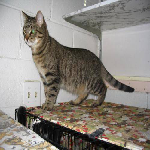

In [36]:
print(train_imgs[1].shape)
array_to_img(train_imgs[300])

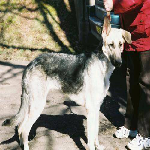

In [37]:
array_to_img(train_imgs[1700])

In [38]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit(train_labels)
train_labels_enc = le.transform(train_labels)
validation_labels_enc = le.transform(validation_labels)
print(train_labels[1450:1463])
print(train_labels_enc[1450:1463])

['dog', 'dog', 'dog', 'dog', 'dog', 'dog', 'dog', 'dog', 'dog', 'dog', 'dog', 'dog', 'dog']
[1 1 1 1 1 1 1 1 1 1 1 1 1]


In [39]:
from keras.applications import vgg16, resnet
from keras.models import Model
import keras

input_shape = (150, 150, 3)

In [40]:
vgg = vgg16.VGG16(include_top=False, weights='imagenet', input_shape=input_shape)
output = vgg.layers[-1].output
output = keras.layers.Flatten()(output)
vgg_model = Model(vgg.input, output)
vgg_model.trainable = False
for layer in vgg_model.layers:
    layer.trainable = False

In [41]:
import pandas as pd
pd.set_option('display.max_colwidth', None)
layers = [(layer, layer.name, layer.trainable) for layer in vgg_model.layers]
pd.DataFrame(layers, columns=['Layer Type', 'Layer Name', 'Layer Trainable'])

,Layer Type,Layer Name,Layer Trainable
0,"<InputLayer name=input_layer_1, built=True>",input_layer_1,False
1,"<Conv2D name=block1_conv1, built=True>",block1_conv1,False
2,"<Conv2D name=block1_conv2, built=True>",block1_conv2,False
3,"<MaxPooling2D name=block1_pool, built=True>",block1_pool,False
4,"<Conv2D name=block2_conv1, built=True>",block2_conv1,False
5,"<Conv2D name=block2_conv2, built=True>",block2_conv2,False
6,"<MaxPooling2D name=block2_pool, built=True>",block2_pool,False
7,"<Conv2D name=block3_conv1, built=True>",block3_conv1,False
8,"<Conv2D name=block3_conv2, built=True>",block3_conv2,False
9,"<Conv2D name=block3_conv3, built=True>",block3_conv3,False


In [42]:
resnet = resnet.ResNet50(include_top=False, weights='imagenet', input_shape=input_shape)
output = resnet.layers[-1].output
output = keras.layers.Flatten()(output)
resnet_model = Model(resnet.input, output)
resnet_model.trainable = False
for layer in resnet_model.layers:
    layer.trainable = False

In [43]:
import pandas as pd
pd.set_option('display.max_colwidth', None)
layers = [(layer, layer.name, layer.trainable) for layer in resnet_model.layers]
pd.DataFrame(layers, columns=['Layer Type', 'Layer Name', 'Layer Trainable'])

,Layer Type,Layer Name,Layer Trainable
0,"<InputLayer name=input_layer_2, built=True>",input_layer_2,False
1,"<ZeroPadding2D name=conv1_pad, built=True>",conv1_pad,False
2,"<Conv2D name=conv1_conv, built=True>",conv1_conv,False
3,"<BatchNormalization name=conv1_bn, built=True>",conv1_bn,False
4,"<Activation name=conv1_relu, built=True>",conv1_relu,False
...,...,...,...
171,"<Conv2D name=conv5_block3_3_conv, built=True>",conv5_block3_3_conv,False
172,"<BatchNormalization name=conv5_block3_3_bn, built=True>",conv5_block3_3_bn,False
173,"<Add name=conv5_block3_add, built=True>",conv5_block3_add,False
174,"<Activation name=conv5_block3_out, built=True>",conv5_block3_out,False


In [44]:
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, InputLayer
from keras.models import Sequential
from tensorflow.keras import optimizers

In [45]:
modelvgg = Sequential()
modelvgg.add(vgg_model)

modelvgg.add(Dense(512, activation='relu', input_dim=input_shape))
modelvgg.add(Dropout(0.3))

modelvgg.add(Dense(512, activation='relu'))
modelvgg.add(Dropout(0.3))

modelvgg.add(Dense(1, activation='sigmoid'))

modelvgg.compile(
    loss='binary_crossentropy',
    optimizer=optimizers.RMSprop(learning_rate=1e-4),
    metrics=['accuracy']
)

modelvgg.summary()

C:\Users\hansh\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ functional_26 (Functional)      │ (None, 8192)           │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,172,673 (73.14 MB)

 Trainable params: 4,457,985 (17.01 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [46]:
historyvgg = modelvgg.fit(
    x=train_imgs_scaled,
    y=train_labels_enc,
    validation_data=(validation_imgs_scaled, validation_labels_enc),
    batch_size=20,
    epochs=5,
    verbose=1
)

Epoch 1/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 187s 1s/step - accuracy: 0.8118 - loss: 0.4112 - val_accuracy: 0.8801 - val_loss: 0.2719
Epoch 2/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 183s 1s/step - accuracy: 0.8781 - loss: 0.2822 - val_accuracy: 0.9155 - val_loss: 0.2098
Epoch 3/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 212s 2s/step - accuracy: 0.9134 - loss: 0.2119 - val_accuracy: 0.9179 - val_loss: 0.1923
Epoch 4/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 208s 2s/step - accuracy: 0.9210 - loss: 0.1840 - val_accuracy: 0.9329 - val_loss: 0.1723
Epoch 5/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 182s 1s/step - accuracy: 0.9341 - loss: 0.1580 - val_accuracy: 0.9209 - val_loss: 0.1897


In [47]:
modelvgg.save('./myVGGmodel.keras')

In [48]:
from tensorflow import keras
modelvgg = keras.models.load_model('./myVGGmodel.keras')

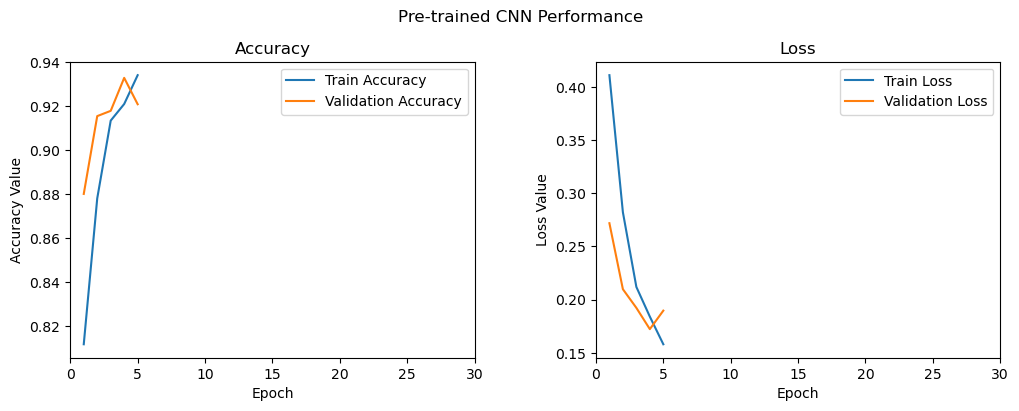

In [49]:
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
t = f.suptitle('Pre-trained CNN Performance', fontsize=12)
f.subplots_adjust(top=0.85, wspace=0.3)

epoch_list = range(1, len(historyvgg.history['accuracy']) + 1)

ax1.plot(epoch_list, historyvgg.history['accuracy'], label='Train Accuracy')
ax1.plot(epoch_list, historyvgg.history['val_accuracy'], label='Validation Accuracy')

ax1.set_xticks(np.arange(0, 31, 5))
ax1.set_ylabel('Accuracy Value')
ax1.set_xlabel('Epoch')
ax1.set_title('Accuracy')
l1 = ax1.legend(loc="best")

ax2.plot(epoch_list, historyvgg.history['loss'], label='Train Loss')
ax2.plot(epoch_list, historyvgg.history['val_loss'], label='Validation Loss')

ax2.set_xticks(np.arange(0, 31, 5))
ax2.set_ylabel('Loss Value')
ax2.set_xlabel('Epoch')
ax2.set_title('Loss')
l2 = ax2.legend(loc="best")
plt.show()

In [50]:
import matplotlib.image as img
import matplotlib.pyplot as plt  # Added import for plt
import numpy as np  # Added import for np


In [ ]:
import os
print("cat.jpg:", os.getcwd())
print("Current working directory:", os.getcwd())
print("Files in directory:", os.listdir())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
Pred prob(cat): 0.0009936117567121983
It seems to be cat


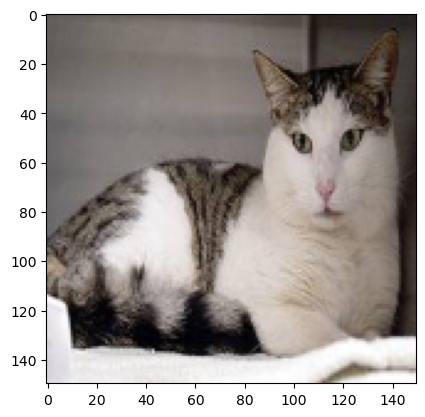

In [78]:
cat = img.imread('dogs-vs-cats/cat.50.jpg')

#cat = img.imread('cat.jpg')

from skimage.transform import resize 
resized_cat = resize(cat, (150, 150, 3))
plt.imshow(resized_cat, cmap='gray')

classes = ['cat', 'dog']
pred = modelvgg.predict(np.expand_dims(resized_cat, 0))
pred_value = float(pred.squeeze())      # convert to scalar
pred_idx = int(pred_value >= 0.5)       # threshold

print("Pred prob(cat):", pred_value)
print("It seems to be", classes[pred_idx])

plt.show()






1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step
It seems to be dog


C:\Users\hansh\AppData\Local\Temp\ipykernel_11660\1483131941.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("It seems to be", classes[int(np.round(pred))])


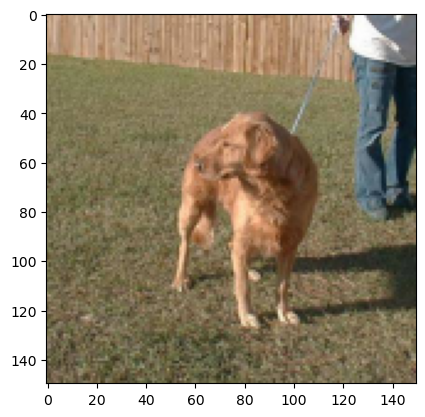

In [74]:
dog = img.imread('dogs-vs-cats/dog.5454.jpg')



from skimage.transform import resize 

resized_dog = resize(dog, (150, 150, 3))
plt.imshow(resized_dog, cmap='gray')

classes = ['cat', 'dog']
pred = modelvgg.predict(np.expand_dims(resized_dog, 0))
print("It seems to be", classes[int(np.round(pred))])
plt.show()



